In [218]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import norm
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

import joblib

In [170]:
aapl = pd.read_csv("data/processed/AAPL_cleaned.csv")
aapl["date"] = pd.to_datetime(aapl["date"])
aapl["exdate"] = pd.to_datetime(aapl["exdate"])

print(aapl.shape)
aapl.head()

(838276, 19)


,secid,date,exdate,strike_price,best_bid,best_offer,volume,open_interest,optionid,close,moneyness (S/K),price,volatility,rate,days_to_maturity,T,last_dividend,frequency,q
0,101594,2020-08-31,2020-09-04,100.00,29.4,29.7,150,411,135212375,129.04,1.290400,29.55,0.375779,0.002148,4,0.010959,0.205,3,0.004766
1,101594,2020-08-31,2020-11-20,80.00,50.1,50.5,0,343,134244951,129.04,1.613000,50.30,0.375779,0.002148,81,0.221918,0.205,3,0.004766
2,101594,2020-08-31,2020-11-20,81.25,48.9,49.3,1,416,134244952,129.04,1.588185,49.10,0.375779,0.002148,81,0.221918,0.205,3,0.004766
3,101594,2020-08-31,2020-11-20,82.50,47.7,48.1,16,383,134244953,129.04,1.564121,47.90,0.375779,0.002148,81,0.221918,0.205,3,0.004766
4,101594,2020-08-31,2020-11-20,83.75,46.5,46.9,0,414,134244954,129.04,1.540776,46.70,0.375779,0.002148,81,0.221918,0.205,3,0.004766


### Black-Scholes benchmark (call formula)

The closed-form Black-Scholes price is computed for each option as the benchmark against which the machine learning models will later be compared. Since the analysis is restricted to call options, only the call formula is implemented:

C = S·e^(-qT)·N(d1) − K·e^(-rT)·N(d2)

d1 = [ln(S/K) + (r − q + σ²/2)T] / (σ√T)

d2 = d1 − σ√T

In [171]:
d1 = (
    np.log(aapl["close"] / aapl["strike_price"])
    + (aapl["rate"] - aapl["q"] + 0.5 * aapl["volatility"] ** 2) * aapl["T"]
) / (aapl["volatility"] * np.sqrt(aapl["T"]))

d2 = d1 - aapl["volatility"] * np.sqrt(aapl["T"])

In [172]:
aapl["bs_price"] = (
    aapl["close"] * np.exp(-aapl["q"] * aapl["T"]) * norm.cdf(d1)
    - aapl["strike_price"] * np.exp(-aapl["rate"] * aapl["T"]) * norm.cdf(d2)
)

aapl["bs_price"].describe()

count    838276.000000
mean         34.851495
std          42.635250
min           0.000000
25%           1.404682
50%          16.424608
75%          57.070649
max         253.989479
Name: bs_price, dtype: float64

In [173]:
aapl["bs_error"] = aapl["price"] - aapl["bs_price"]

print(aapl["bs_error"].describe())

count    838276.000000
mean          0.145050
std           1.815228
min         -26.296163
25%          -0.047267
50%           0.141726
75%           0.597371
max           8.431758
Name: bs_error, dtype: float64


In [174]:
print(aapl.nlargest(5, "bs_error")[["date", "moneyness (S/K)", "T", "volatility", "price", "bs_price"]])
print()
print(aapl.nsmallest(5, "bs_error")[["date", "moneyness (S/K)", "T", "volatility", "price", "bs_price"]])

             date  moneyness (S/K)    T  volatility   price   bs_price
709640 2024-12-19         1.019551  1.0    0.160031  32.925  24.493242
709642 2024-12-19         0.999160  1.0    0.160031  30.025  21.617085
709652 2024-12-19         0.979569  1.0    0.160031  27.375  18.973291
709639 2024-12-19         1.040792  1.0    0.160031  35.950  27.598717
709643 2024-12-19         0.960731  1.0    0.160031  24.825  16.561278

             date  moneyness (S/K)         T  volatility   price   bs_price
783813 2025-05-13         0.851720  0.852055    0.596494   9.825  36.121163
783117 2025-05-12         0.843160  0.854795    0.597661   8.925  35.190170
783116 2025-05-12         0.878292  0.854795    0.597661  12.025  38.209632
783812 2025-05-13         0.887208  0.852055    0.596494  13.075  39.204280
783814 2025-05-13         0.818962  0.852055    0.596494   7.275  33.283936


The dataset is split chronologically by trading date rather than by random row sampling, to avoid look-ahead bias: the earliest ~70% of dates form the training set, the following ~15% the validation set, and the final ~15% the held-out test set. Feature selection follows Hutchinson, Lo and Poggio (1994), using moneyness (S/K) in place of S and K as separate inputs.

### Diagnostic: Black-Scholes error by moneyness bucket

Before introducing any machine learning model, the Black-Scholes benchmark error is broken down by moneyness bucket on the validation set. This step is diagnostic: it checks whether the very low *aggregate* Black-Scholes error (computed above) is genuinely representative, or whether it is an artifact of the dataset composition (e.g. a large share of deep in-the-money contracts, for which price is close to intrinsic value and therefore near-trivial to predict).

In [175]:
aapl_check = aapl.copy()
aapl_check["bs_error_abs"] = np.abs(aapl_check["price"] - aapl_check["bs_price"])

bins = [0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100]
labels = ["deep OTM", "OTM", "ATM", "ITM", "deep ITM", "very deep ITM", "extreme ITM"]
aapl_check["moneyness_bucket"] = pd.cut(aapl_check["moneyness (S/K)"], bins=bins, labels=labels)

print(aapl_check.groupby("moneyness_bucket")["bs_error_abs"].agg(["mean", "count"]))

                      mean   count
moneyness_bucket                  
deep OTM          0.713376  151958
OTM               1.064059  139972
ATM               1.282396  101201
ITM               1.088711  119303
deep ITM          0.746260  209028
very deep ITM     0.312688  103232
extreme ITM       0.249054   13582


### Dataset split

In [176]:
aapl = aapl.sort_values("date").reset_index(drop=True)

train_cutoff = aapl["date"].quantile(0.70)
val_cutoff = aapl["date"].quantile(0.85)

train = aapl[aapl["date"] <= train_cutoff]
val = aapl[(aapl["date"] > train_cutoff) & (aapl["date"] <= val_cutoff)]
test = aapl[aapl["date"] > val_cutoff]

print(f"Train: {len(train)} rows, {train['date'].min()} to {train['date'].max()}")
print(f"Validation: {len(val)} rows, {val['date'].min()} to {val['date'].max()}")
print(f"Test: {len(test)} rows, {test['date'].min()} to {test['date'].max()}")

Train: 587104 rows, 2020-08-31 00:00:00 to 2024-03-27 00:00:00
Validation: 125955 rows, 2024-03-28 00:00:00 to 2024-12-26 00:00:00
Test: 125217 rows, 2024-12-27 00:00:00 to 2025-08-29 00:00:00


In [177]:
feature_cols = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
target_col = "price"

X_train, y_train = train[feature_cols], train[target_col]
X_val, y_val = val[feature_cols], val[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print("Feature columns:", feature_cols)
print("Target column:", target_col)

Feature columns: ['moneyness (S/K)', 'T', 'rate', 'q', 'volatility']
Target column: price


### XGBoost baseline model

A gradient-boosted tree model (XGBoost) is trained on the chronological training set, using the validation set for early stopping to prevent overfitting. Default/simple hyperparameters are used for this initial baseline; tuning is deferred to a later iteration.

This first model (baseline) uses the same five inputs as the Black-Scholes benchmark, with the raw option price as target.

In [178]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Best iteration: {model.best_iteration}")
print(f"Best validation RMSE: {model.best_score:.4f}")

Best iteration: 242
Best validation RMSE: 10.7806


In [179]:
val_pred = model.predict(X_val)

val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
val_mae = mean_absolute_error(y_val, val_pred)
val_r2 = r2_score(y_val, val_pred)

print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation R²: {val_r2:.4f}")

Validation RMSE: 10.7806
Validation MAE: 6.2027
Validation R²: 0.9624


In [180]:
# Baseline XGBoost vs Black-Scholes — error by moneyness bucket (validation set)
val_check_baseline = val.copy()
val_check_baseline["xgb_baseline_pred"] = val_pred
val_check_baseline["xgb_baseline_error_abs"] = (val_check_baseline["price"] - val_check_baseline["xgb_baseline_pred"]).abs()
val_check_baseline["bs_error_abs"] = (val_check_baseline["price"] - val_check_baseline["bs_price"]).abs()

val_check_baseline["moneyness_bucket"] = pd.cut(
    val_check_baseline["moneyness (S/K)"],
    bins=[0, 0.85, 1.0, 1.15, np.inf],
    labels=["Deep OTM", "OTM/ATM", "ITM", "Deep ITM"]
)

val_check_baseline.groupby("moneyness_bucket")[["bs_error_abs", "xgb_baseline_error_abs"]].mean()

,bs_error_abs,xgb_baseline_error_abs
moneyness_bucket,,
Deep OTM,0.392923,0.327875
OTM/ATM,1.011455,1.041740
ITM,1.064149,2.942349
Deep ITM,0.426695,11.949613


### Experiment (v2): separate S and K, log-transformed target

This configuration replaces moneyness with the underlying price and strike as separate inputs, and switches the target to `log1p(price)` (predictions are converted back with `expm1`). It is compared against Black-Scholes by moneyness bucket, both in absolute and percentage error.

In [181]:
feature_cols_v2 = ["close", "strike_price", "T", "rate", "q", "volatility"]

X_train_v2, X_val_v2 = train[feature_cols_v2], val[feature_cols_v2]

y_train_log = np.log1p(train["price"])
y_val_log = np.log1p(val["price"])

In [182]:
model_v2 = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42
)

model_v2.fit(X_train_v2, y_train_log, eval_set=[(X_val_v2, y_val_log)], verbose=False)

print(f"Best iteration: {model_v2.best_iteration}")

Best iteration: 513


In [183]:
val_pred_v2 = np.expm1(model_v2.predict(X_val_v2))

rmse_v2 = np.sqrt(mean_squared_error(val["price"], val_pred_v2))
mae_v2 = mean_absolute_error(val["price"], val_pred_v2)

print(f"XGBoost v2 — RMSE: {rmse_v2:.4f}, MAE: {mae_v2:.4f}")

val_check = val.copy()
val_check["xgb_v2_error_abs"] = np.abs(val_check["price"] - val_pred_v2)
val_check["bs_error_abs"] = np.abs(val_check["price"] - val_check["bs_price"])

bins = [0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100]
labels = ["deep OTM", "OTM", "ATM", "ITM", "deep ITM", "very deep ITM", "extreme ITM"]
val_check["moneyness_bucket"] = pd.cut(val_check["moneyness (S/K)"], bins=bins, labels=labels)

print(val_check.groupby("moneyness_bucket")[["bs_error_abs", "xgb_v2_error_abs"]].agg(["mean", "count"]))

XGBoost v2 — RMSE: 20.0309, MAE: 13.4633
                 bs_error_abs        xgb_v2_error_abs       
                         mean  count             mean  count
moneyness_bucket                                            
deep OTM             0.302312  20297         0.407706  20297
OTM                  0.834901  21772         2.124793  21772
ATM                  1.195201  14114         7.114092  14114
ITM                  0.943610  16250        17.132812  16250
deep ITM             0.496165  32936        23.699346  32936
very deep ITM        0.226069  16442        24.065000  16442
extreme ITM          0.216732   4144        20.796290   4144


In [184]:
# Black-Scholes, normalized (C/X)
bs_pred_norm = val["bs_price"] / val["strike_price"]

# XGBoost v2, normalized (C/X)
xgb_pred_norm = val_pred_v2 / val["strike_price"]

# True target, normalized (C/X)
true_norm = val["price"] / val["strike_price"]

bs_r2_norm = r2_score(true_norm, bs_pred_norm)
xgb_r2_norm = r2_score(true_norm, xgb_pred_norm)

bs_rmse_norm = np.sqrt(mean_squared_error(true_norm, bs_pred_norm))
xgb_rmse_norm = np.sqrt(mean_squared_error(true_norm, xgb_pred_norm))

print(f"Black-Scholes — R² (C/X): {bs_r2_norm:.4f}, RMSE (C/X): {bs_rmse_norm:.4f}")
print(f"XGBoost       — R² (C/X): {xgb_r2_norm:.4f}, RMSE (C/X): {xgb_rmse_norm:.4f}")

Black-Scholes — R² (C/X): 1.0000, RMSE (C/X): 0.0083
XGBoost       — R² (C/X): 0.9836, RMSE (C/X): 0.5037


In [185]:
reasonable_mask = val["moneyness (S/K)"].between(0.7, 1.3)

bs_r2_reasonable = r2_score(val.loc[reasonable_mask, "price"], val.loc[reasonable_mask, "bs_price"])
xgb_r2_reasonable = r2_score(val.loc[reasonable_mask, "price"], val_pred_v2[reasonable_mask.values])

print(f"Righe nel range 0.7-1.3 moneyness: {reasonable_mask.sum()} su {len(val)}")
print(f"Black-Scholes — R² (moneyness 0.7-1.3): {bs_r2_reasonable:.4f}")
print(f"XGBoost       — R² (moneyness 0.7-1.3): {xgb_r2_reasonable:.4f}")

Righe nel range 0.7-1.3 moneyness: 70859 su 125955
Black-Scholes — R² (moneyness 0.7-1.3): 0.9929
XGBoost       — R² (moneyness 0.7-1.3): 0.2702


In [186]:
val_check["xgb_v2_pct_error"] = val_check["xgb_v2_error_abs"] / val_check["price"] * 100
val_check["bs_pct_error"] = val_check["bs_error_abs"] / val_check["price"] * 100

print(val_check.groupby("moneyness_bucket")[["bs_pct_error", "xgb_v2_pct_error"]].mean())

                  bs_pct_error  xgb_v2_pct_error
moneyness_bucket                                
deep OTM             77.758907         78.705190
OTM                  56.455658         96.114071
ATM                  19.336024         85.860526
ITM                   3.335738         61.474790
deep ITM              0.784742         33.305513
very deep ITM         0.166602         16.692519
extreme ITM           0.113283         10.151832


### Best configuration (v3): moneyness input + log-transformed target

This configuration keeps the same five inputs as the baseline (moneyness in place of S and K separately) but switches the target to `log1p(price)`, as in v2. Of the configurations tested, this is the one retained as the current XGBoost baseline for further work (hyperparameter tuning, SPX comparison, etc.).

In [187]:
feature_cols_v3 = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
X_train_v3, X_val_v3 = train[feature_cols_v3], val[feature_cols_v3]

model_v3 = xgb.XGBRegressor(
    n_estimators=1000, 
    early_stopping_rounds=50, 
    eval_metric="rmse", 
    random_state=42
)
model_v3.fit(X_train_v3, y_train_log, eval_set=[(X_val_v3, y_val_log)], verbose=False)

val_pred_v3 = np.expm1(model_v3.predict(X_val_v3))

v3_check = val.copy()
v3_check["xgb_v3_error_abs"] = np.abs(v3_check["price"] - val_pred_v3)
v3_check["xgb_v3_pct_error"] = v3_check["xgb_v3_error_abs"] / v3_check["price"] * 100
v3_check["bs_error_abs"] = np.abs(v3_check["price"] - v3_check["bs_price"])
v3_check["bs_pct_error"] = v3_check["bs_error_abs"] / v3_check["price"] * 100

v3_check["moneyness_bucket"] = pd.cut(
    v3_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

print(v3_check.groupby("moneyness_bucket")[["bs_error_abs", "xgb_v3_error_abs", "bs_pct_error", "xgb_v3_pct_error"]].mean())

                  bs_error_abs  xgb_v3_error_abs  bs_pct_error  \
moneyness_bucket                                                 
Deep OTM              0.302312          0.236246     77.758907   
OTM                   0.834901          0.768305     56.455658   
ATM                   1.195201          1.947635     19.336024   
ITM                   0.943610          4.159996      3.335738   
Deep ITM              0.496165          9.752418      0.784742   
Very Deep ITM         0.226069         19.505724      0.166602   
Extreme ITM           0.216732         29.370400      0.113283   

                  xgb_v3_pct_error  
moneyness_bucket                    
Deep OTM                 65.830051  
OTM                      60.540744  
ATM                      28.552954  
ITM                      14.697168  
Deep ITM                 12.756547  
Very Deep ITM            13.357519  
Extreme ITM              14.354146  


### v4

In [188]:
feature_cols_v4 = ["moneyness (S/K)", "strike_price", "T", "rate", "q", "volatility"]

X_train_v4 = train[feature_cols_v4]
X_val_v4 = val[feature_cols_v4]

model_v4 = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42
)
model_v4.fit(X_train_v4, y_train_log, eval_set=[(X_val_v4, y_val_log)], verbose=False)

val_pred_v4 = np.expm1(model_v4.predict(X_val_v4))

v4_check = val.copy()
v4_check["xgb_v4_pred"] = val_pred_v4
v4_check["xgb_v4_error_abs"] = np.abs(v4_check["price"] - v4_check["xgb_v4_pred"])
v4_check["bs_error_abs"] = np.abs(v4_check["price"] - v4_check["bs_price"])

v4_check["moneyness_bucket"] = pd.cut(
    v4_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

xgb_v4_bucket_summary = v4_check.groupby("moneyness_bucket").agg(
    n_options=("xgb_v4_error_abs", "size"),
    bs_mae=("bs_error_abs", "mean"),
    xgb_v4_mae=("xgb_v4_error_abs", "mean"),
)
xgb_v4_bucket_summary["ratio_v4_vs_bs"] = xgb_v4_bucket_summary["xgb_v4_mae"] / xgb_v4_bucket_summary["bs_mae"]

xgb_v4_bucket_summary

,n_options,bs_mae,xgb_v4_mae,ratio_v4_vs_bs
moneyness_bucket,,,,
Deep OTM,20297,0.302312,0.250743,0.829420
OTM,21772,0.834901,0.736243,0.881833
ATM,14114,1.195201,1.796923,1.503449
ITM,16250,0.943610,3.405529,3.609042
Deep ITM,32936,0.496165,9.461616,19.069491
Very Deep ITM,16442,0.226069,18.376371,81.286696
Extreme ITM,4144,0.216732,27.697878,127.797663


## v5 - normalized target price/k

In [226]:
# v5: same 5 inputs as v3, but target normalized by strike — log1p(price / K)
feature_cols_v5 = ["moneyness (S/K)", "T", "rate", "q", "volatility"]

X_train_v5 = train[feature_cols_v5]
X_val_v5 = val[feature_cols_v5]

y_train_ratio_log = np.log1p(train["price"].values / train["strike_price"].values)
y_val_ratio_log = np.log1p(val["price"].values / val["strike_price"].values)

model_v5 = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42
)
model_v5.fit(X_train_v5, y_train_ratio_log, eval_set=[(X_val_v5, y_val_ratio_log)], verbose=False)

# invert: expm1 gives price/K, then multiply back by K
val_pred_v5 = np.expm1(model_v5.predict(X_val_v5)) * val["strike_price"].values

v5_check = val.copy()
v5_check["xgb_v5_pred"] = val_pred_v5
v5_check["xgb_v5_error_abs"] = np.abs(v5_check["price"] - v5_check["xgb_v5_pred"])
v5_check["bs_error_abs"] = np.abs(v5_check["price"] - v5_check["bs_price"])

v5_check["moneyness_bucket"] = pd.cut(
    v5_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

xgb_v5_bucket_summary = v5_check.groupby("moneyness_bucket").agg(
    n_options=("xgb_v5_error_abs", "size"),
    bs_mae=("bs_error_abs", "mean"),
    xgb_v5_mae=("xgb_v5_error_abs", "mean"),
)
xgb_v5_bucket_summary["ratio_v5_vs_bs"] = xgb_v5_bucket_summary["xgb_v5_mae"] / xgb_v5_bucket_summary["bs_mae"]

xgb_v5_bucket_summary

,n_options,bs_mae,xgb_v5_mae,ratio_v5_vs_bs
moneyness_bucket,,,,
Deep OTM,20297,0.302312,0.890909,2.946991
OTM,21772,0.834901,1.036569,1.241547
ATM,14114,1.195201,1.308784,1.095033
ITM,16250,0.943610,0.939408,0.995547
Deep ITM,32936,0.496165,0.720667,1.452474
Very Deep ITM,16442,0.226069,2.455068,10.859837
Extreme ITM,4144,0.216732,115.532839,533.067071


## Systematic hyperparameter tuning via rolling-window cross-validation

Grid search over XGBoost hyperparameters, evaluated with rolling-window (walk-forward) cross-validation to preserve chronological ordering and avoid look-ahead bias, per Ruf & Wang (2021). Cross-validation is performed only within the combined train+validation period (85% of dates); the held-out test set remains untouched until the final evaluation.

Window design: 18-month training window, 3-month validation window, 3-month step (non-overlapping validation folds). Features and target follow the best configuration found above (v6): moneyness, T, rate, q, volatility, with `log1p(price)` as target.

In [189]:
# Build rolling-window folds: 24-month train, 6-month validation, 6-month step
train_val = pd.concat([train, val]).sort_values("date").reset_index(drop=True)

start_date = train_val["date"].min()
end_date = train_val["date"].max()

fold_boundaries = []
fold_start = start_date

while True:
    train_end = fold_start + pd.DateOffset(months=24)
    if train_end >= end_date:
        break

    val_end = min(train_end + pd.DateOffset(months=6), end_date)
    fold_boundaries.append((fold_start, train_end, val_end))

    if val_end >= end_date:
        break

    fold_start = fold_start + pd.DateOffset(months=6)

print(f"Number of folds: {len(fold_boundaries)}")
for i, (ts, te, ve) in enumerate(fold_boundaries):
    n_val_days = (ve - te).days
    print(f"Fold {i+1}: train [{ts.date()} -> {te.date()}], val [{te.date()} -> {ve.date()}] ({n_val_days} days)")

Number of folds: 5
Fold 1: train [2020-08-31 -> 2022-08-31], val [2022-08-31 -> 2023-02-28] (181 days)
Fold 2: train [2021-02-28 -> 2023-02-28], val [2023-02-28 -> 2023-08-28] (181 days)
Fold 3: train [2021-08-28 -> 2023-08-28], val [2023-08-28 -> 2024-02-28] (184 days)
Fold 4: train [2022-02-28 -> 2024-02-28], val [2024-02-28 -> 2024-08-28] (182 days)
Fold 5: train [2022-08-28 -> 2024-08-28], val [2024-08-28 -> 2024-12-26] (120 days)


In [190]:
# Define hyperparameter grid for XGBoost
import itertools

param_grid = {
    "max_depth": [5, 7, 9, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 300, 500],
    "subsample": [0.8, 1.0],
    # "colsample_bytree": [0.8, 1.0]
}

param_combinations = list(itertools.product(*param_grid.values()))
param_names = list(param_grid.keys())

print(f"Total combinations to test: {len(param_combinations)}")
print(f"Total model fits: {len(param_combinations) * len(fold_boundaries)}")

Total combinations to test: 72
Total model fits: 360


In [191]:
# Run rolling-window CV grid search
cv_feature_cols = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
cv_target_col = "price"

cv_results = []

for combo in param_combinations:
    params = dict(zip(param_names, combo))
    fold_rmses = []

    for (fold_train_start, fold_train_end, fold_val_end) in fold_boundaries:
        fold_train = train_val[
            (train_val["date"] >= fold_train_start) & (train_val["date"] < fold_train_end)
        ]
        fold_val = train_val[
            (train_val["date"] >= fold_train_end) & (train_val["date"] < fold_val_end)
        ]

        X_fold_train = fold_train[cv_feature_cols]
        y_fold_train_log = np.log1p(fold_train[cv_target_col])
        X_fold_val = fold_val[cv_feature_cols]
        y_fold_val = fold_val[cv_target_col]

        fold_model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1)
        fold_model.fit(X_fold_train, y_fold_train_log)

        y_fold_pred = np.expm1(fold_model.predict(X_fold_val))
        fold_rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_pred))
        fold_rmses.append(fold_rmse)

    cv_results.append({
        **params,
        "mean_rmse": np.mean(fold_rmses),
        "std_rmse": np.std(fold_rmses)
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("mean_rmse")
cv_results_df.head(10)

,max_depth,learning_rate,n_estimators,subsample,mean_rmse,std_rmse
70,10,0.10,500,0.8,3.383368,1.966825
29,7,0.05,500,1.0,3.398583,2.105324
68,10,0.10,300,0.8,3.412775,1.998131
34,7,0.10,500,0.8,3.431255,2.143551
52,9,0.10,500,0.8,3.431614,2.077567
47,9,0.05,500,1.0,3.440533,2.108322
28,7,0.05,500,0.8,3.440613,2.136959
71,10,0.10,500,1.0,3.442981,2.073830
27,7,0.05,300,1.0,3.445450,2.161471
32,7,0.10,300,0.8,3.451978,2.158453


Note that we have a high standard RMSE of about 60%, this means that the performance of the mdoel depends strongly on the market period that is considered as validation fold. in the next cell we'll analyze the error fold by fold considering the top 5 combinations of parameters.

In [192]:
# Fold-by-fold RMSE for the top N hyperparameter combinations
top_n = 5
top_combos = cv_results_df.head(top_n)[param_names].to_dict("records")

detailed_results = []

for params in top_combos:
    fold_rmses = []

    for (fold_train_start, fold_train_end, fold_val_end) in fold_boundaries:
        fold_train = train_val[
            (train_val["date"] >= fold_train_start) & (train_val["date"] < fold_train_end)
        ]
        fold_val = train_val[
            (train_val["date"] >= fold_train_end) & (train_val["date"] < fold_val_end)
        ]

        X_fold_train = fold_train[cv_feature_cols]
        y_fold_train_log = np.log1p(fold_train[cv_target_col])
        X_fold_val = fold_val[cv_feature_cols]
        y_fold_val = fold_val[cv_target_col]

        fold_model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1)
        fold_model.fit(X_fold_train, y_fold_train_log)

        y_fold_pred = np.expm1(fold_model.predict(X_fold_val))
        fold_rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_pred))
        fold_rmses.append(fold_rmse)

    detailed_results.append({**params, **{f"fold_{i+1}_rmse": r for i, r in enumerate(fold_rmses)}})

detailed_df = pd.DataFrame(detailed_results)
detailed_df

,max_depth,learning_rate,n_estimators,subsample,fold_1_rmse,fold_2_rmse,fold_3_rmse,fold_4_rmse,fold_5_rmse
0,10,0.10,500,0.8,0.728140,2.917552,2.472005,6.647378,4.151763
1,7,0.05,500,1.0,0.796226,2.825247,2.143141,6.968285,4.260014
2,10,0.10,300,0.8,0.736665,2.924169,2.496510,6.756260,4.150271
3,7,0.10,500,0.8,0.710896,2.956408,2.110808,6.994664,4.383499
4,9,0.10,500,0.8,0.762028,2.828580,2.404444,6.958445,4.204575


In [193]:
aapl.groupby(aapl["date"].dt.to_period("M"))["volatility"].mean().loc["2024-02":"2024-12"]

date
2024-02    0.192166
2024-03    0.186249
2024-04    0.215737
2024-05    0.257983
2024-06    0.271440
2024-07    0.273413
2024-08    0.266121
2024-09    0.226269
2024-10    0.215182
2024-11    0.203785
2024-12    0.160666
Freq: M, Name: volatility, dtype: float64

In [194]:
# Final model: retrain on full train+validation with best hyperparameters from CV
best_params = cv_results_df.iloc[0][param_names].to_dict()
# ensure correct types (grid values may come back as numpy types)
best_params = {k: (int(v) if k in ["max_depth", "n_estimators"] else float(v)) for k, v in best_params.items()}

print("Best hyperparameters selected via rolling-window CV:")
print(best_params)

final_model = xgb.XGBRegressor(**best_params, random_state=42, n_jobs=-1)

X_train_val = train_val[cv_feature_cols]
y_train_val_log = np.log1p(train_val[cv_target_col])

final_model.fit(X_train_val, y_train_val_log)

Best hyperparameters selected via rolling-window CV:
{'max_depth': 10, 'learning_rate': 0.1, 'n_estimators': 500, 'subsample': 0.8}


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [195]:
# Evaluate final model on the untouched test set — once
X_test = test[cv_feature_cols]
y_test = test[cv_target_col]

y_test_pred = np.expm1(final_model.predict(X_test))

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Final XGBoost (tuned) — Test set")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R²:   {test_r2:.4f}")

Final XGBoost (tuned) — Test set
RMSE: 5.8386
MAE:  3.4472
R²:   0.9886


In [196]:
# Compare tuned XGBoost vs Black-Scholes on the test set, by moneyness bucket
test_check = test.copy()
test_check["xgb_final_pred"] = y_test_pred
test_check["xgb_final_error_abs"] = (test_check["price"] - test_check["xgb_final_pred"]).abs()
test_check["bs_error_abs"] = (test_check["price"] - test_check["bs_price"]).abs()

test_check["moneyness_bucket"] = pd.cut(
    test_check["moneyness (S/K)"],
    bins=[0, 0.85, 1.0, 1.15, np.inf],
    labels=["Deep OTM", "OTM/ATM", "ITM", "Deep ITM"]
)

test_check.groupby("moneyness_bucket")[["bs_error_abs", "xgb_final_error_abs"]].mean()

,bs_error_abs,xgb_final_error_abs
moneyness_bucket,,
Deep OTM,2.191287,0.254934
OTM/ATM,2.740581,1.233182
ITM,2.501921,2.707199
Deep ITM,0.920870,6.657147


In [197]:
test_check.groupby("moneyness_bucket").size()

moneyness_bucket
Deep OTM    33822
OTM/ATM     21788
ITM         17020
Deep ITM    52587
dtype: int64

At the bottom there is a much more specific analysis per bucket

In [198]:
# 7-bucket version of the final XGBoost vs BS comparison (AAPL test set)
test_check["moneyness_bucket"] = pd.cut(
    test_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

xgb_final_bucket_summary = test_check.groupby("moneyness_bucket").agg(
    n_options=("bs_error_abs", "size"),
    bs_mae=("bs_error_abs", "mean"),
    xgb_mae=("xgb_final_error_abs", "mean"),
)
xgb_final_bucket_summary["pct_of_test"] = (xgb_final_bucket_summary["n_options"] / xgb_final_bucket_summary["n_options"].sum()) * 100
xgb_final_bucket_summary["ratio_xgb_vs_bs"] = xgb_final_bucket_summary["xgb_mae"] / xgb_final_bucket_summary["bs_mae"]

xgb_final_bucket_summary

,n_options,bs_mae,xgb_mae,pct_of_test,ratio_xgb_vs_bs
moneyness_bucket,,,,,
Deep OTM,26376,2.090844,0.192260,21.064232,0.091953
OTM,22324,2.635443,0.799565,17.828250,0.303389
ATM,13178,2.830286,2.046177,10.524130,0.722958
ITM,15059,2.222774,3.339575,12.026322,1.502436
Deep ITM,31571,1.107418,5.453358,25.213030,4.924389
Very Deep ITM,11824,0.317590,8.964725,9.442807,28.227350
Extreme ITM,4885,0.279314,10.911816,3.901227,39.066552


Training error:

In [202]:
# Train vs test error — AAPL XGBoost final model
X_train_val_check = train_val[cv_feature_cols]
y_train_val_check = train_val["price"]

train_pred_xgb = np.expm1(final_model.predict(X_train_val_check))
train_rmse_xgb = np.sqrt(mean_squared_error(y_train_val_check, train_pred_xgb))
train_mae_xgb = mean_absolute_error(y_train_val_check, train_pred_xgb)

print(f"AAPL XGBoost — Train (train+val): RMSE={train_rmse_xgb:.4f}, MAE={train_mae_xgb:.4f}")
print(f"AAPL XGBoost — Test:              RMSE={test_rmse:.4f}, MAE={test_mae:.4f}")
print(f"Ratio test/train RMSE: {test_rmse/train_rmse_xgb:.2f}x")

AAPL XGBoost — Train (train+val): RMSE=0.4491, MAE=0.1854
AAPL XGBoost — Test:              RMSE=5.8386, MAE=3.4472
Ratio test/train RMSE: 13.00x


In [206]:
# ============================================================
# Overfitting per bucket — AAPL XGBoost (train vs test)
# ============================================================

# Predizioni sul TRAINING set (train+val), per bucket
train_val_check = train_val.copy()
train_val_check["xgb_pred"] = train_pred_xgb  # già calcolato prima (np.expm1(final_model.predict(...)))
train_val_check["xgb_error_abs"] = np.abs(train_val_check["price"] - train_val_check["xgb_pred"])

train_val_check["moneyness_bucket"] = pd.cut(
    train_val_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

train_bucket_mae = train_val_check.groupby("moneyness_bucket")["xgb_error_abs"].mean()

# Confronto con il test (già calcolato in xgb_final_bucket_summary)
overfitting_by_bucket = pd.DataFrame({
    "train_mae": train_bucket_mae,
    "test_mae": xgb_final_bucket_summary["xgb_mae"],
})
overfitting_by_bucket["ratio_test_vs_train"] = overfitting_by_bucket["test_mae"] / overfitting_by_bucket["train_mae"]

overfitting_by_bucket

,train_mae,test_mae,ratio_test_vs_train
moneyness_bucket,,,
Deep OTM,0.019522,0.192260,9.848373
OTM,0.054685,0.799565,14.621372
ATM,0.104270,2.046177,19.623882
ITM,0.143599,3.339575,23.256302
Deep ITM,0.244422,5.453358,22.311216
Very Deep ITM,0.399034,8.964725,22.466068
Extreme ITM,2.220219,10.911816,4.914748


In [199]:
# Verify near-linearity of price vs intrinsic value (S-K) in the Deep ITM bucket
deep_itm = test_check[test_check["moneyness_bucket"] == "Deep ITM"].copy()

deep_itm["intrinsic_value"] = deep_itm["close"] - deep_itm["strike_price"]  # adjust column names if different

# Correlation between price and intrinsic value (should be very high if near-linear)
corr = deep_itm["price"].corr(deep_itm["intrinsic_value"])
print(f"Correlation between price and intrinsic value (Deep ITM): {corr:.4f}")

Correlation between price and intrinsic value (Deep ITM): 0.9901


In [200]:
# Compare how BS and XGBoost residuals relate to intrinsic value
deep_itm["bs_residual"] = deep_itm["price"] - deep_itm["bs_price"]
deep_itm["xgb_residual"] = deep_itm["price"] - deep_itm["xgb_final_pred"]

print("BS residual stats (Deep ITM):")
print(deep_itm["bs_residual"].describe())
print("\nXGBoost residual stats (Deep ITM):")
print(deep_itm["xgb_residual"].describe())

BS residual stats (Deep ITM):
count    31571.000000
mean         0.175946
std          1.963462
min        -16.268822
25%          0.029075
50%          0.402647
75%          1.004666
max          5.319632
Name: bs_residual, dtype: float64

XGBoost residual stats (Deep ITM):
count    31571.000000
mean         5.359200
std          4.468855
min         -3.046524
25%          1.481045
50%          4.345076
75%          8.880935
max         17.666354
Name: xgb_residual, dtype: float64


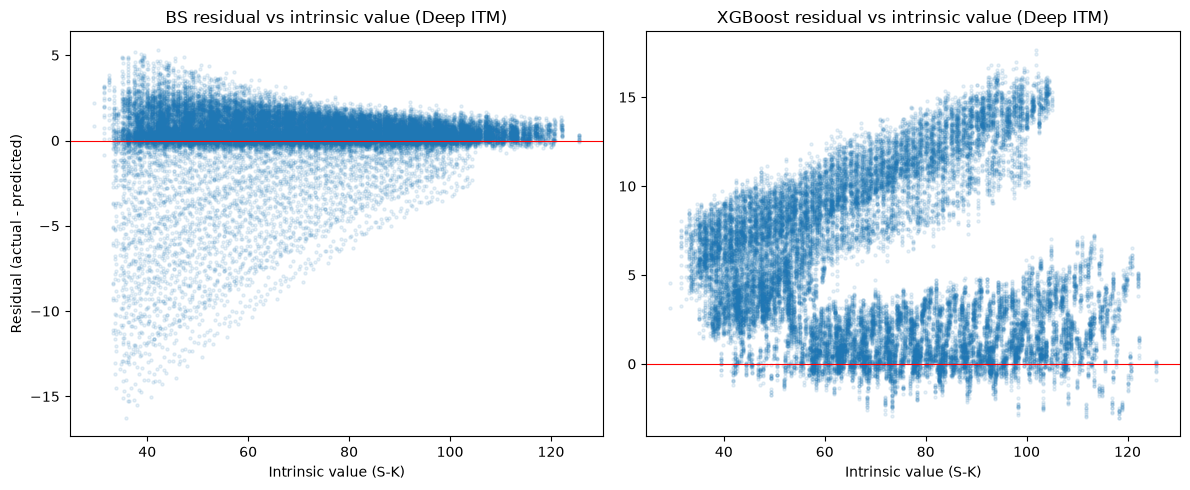

In [201]:
# Visualize: does XGBoost's error grow as intrinsic value grows?
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(deep_itm["intrinsic_value"], deep_itm["bs_residual"], alpha=0.1, s=5)
axes[0].axhline(0, color="red", linewidth=0.8)
axes[0].set_title("BS residual vs intrinsic value (Deep ITM)")
axes[0].set_xlabel("Intrinsic value (S-K)")
axes[0].set_ylabel("Residual (actual - predicted)")

axes[1].scatter(deep_itm["intrinsic_value"], deep_itm["xgb_residual"], alpha=0.1, s=5)
axes[1].axhline(0, color="red", linewidth=0.8)
axes[1].set_title("XGBoost residual vs intrinsic value (Deep ITM)")
axes[1].set_xlabel("Intrinsic value (S-K)")

plt.tight_layout()
plt.show()

L'errore di XGBoost sulle opzioni deep-ITM non è casuale ma sistematico: il modello sottostima progressivamente il prezzo al crescere del valore intrinseco, un pattern coerente con la nota incapacità dei modelli ad albero di estrapolare oltre il range dei valori target osservati in training. Black-Scholes, essendo una formula chiusa che converge analiticamente al valore intrinseco per costruzione, non soffre di questa limitazione."

## Diebold-Mariano test

In [209]:
def diebold_mariano_test(actual, pred1, pred2, dates, loss="squared", lag=None):
    """
    Diebold-Mariano test adapted to panel data following Gu, Kelly & Xiu (2020, eq. 20).
    Loss differentials are averaged cross-sectionally within each date before testing,
    so the unit of observation is the trading day, not the individual contract.
    H0: equal predictive accuracy. d = loss(pred1) - loss(pred2):
    positive d (and positive statistic) means model 1 has the larger loss, i.e. model 2 is better.
    Newey-West HAC variance + Harvey-Leybourne-Newbold (1997) small-sample correction.
    """
    e1 = np.asarray(actual) - np.asarray(pred1)
    e2 = np.asarray(actual) - np.asarray(pred2)

    if loss == "squared":
        d_i = e1**2 - e2**2
    elif loss == "absolute":
        d_i = np.abs(e1) - np.abs(e2)
    else:
        raise ValueError("loss must be 'squared' or 'absolute'")

    # cross-sectional aggregation: one loss differential per date
    d = (pd.DataFrame({"date": np.asarray(dates), "d": d_i})
         .groupby("date")["d"].mean().sort_index().values)

    T = len(d)
    if T < 10:
        return np.nan, np.nan, T
    d_mean = d.mean()
    dev = d - d_mean

    if lag is None:
        lag = int(np.floor(4 * (T / 100) ** (2/9)))

    var_d = np.dot(dev, dev) / T
    for k in range(1, lag + 1):
        gamma_k = np.dot(dev[k:], dev[:-k]) / T
        var_d += 2 * (1 - k / (lag + 1)) * gamma_k

    if var_d <= 0:
        return np.nan, np.nan, T

    dm_stat = d_mean / np.sqrt(var_d / T)
    dm_stat = dm_stat * np.sqrt((T - 1) / T)          # HLN correction, h = 1
    p_value = 2 * stats.t.sf(np.abs(dm_stat), df=T - 1)

    return dm_stat, p_value, T

In [213]:
dm_results_bs_vs_xgb = []
for bucket in test_check["moneyness_bucket"].cat.categories:
    subset = test_check[test_check["moneyness_bucket"] == bucket]
    if len(subset) == 0:
        continue
    dm_stat, p_val, n_days = diebold_mariano_test(
        subset["price"].values,
        subset["bs_price"].values,
        subset["xgb_final_pred"].values,
        subset["date"].values,
        loss="squared"
    )
    dm_results_bs_vs_xgb.append({
        "bucket": bucket,
        "n_obs": len(subset),
        "n_days": n_days,
        "dm_stat": dm_stat,
        "p_value": p_val,
        "better": ("XGBoost" if dm_stat > 0 else "BS") if p_val < 0.05 else "no diff."
    })

dm_bs_vs_xgb_df = pd.DataFrame(dm_results_bs_vs_xgb)
dm_bs_vs_xgb_df

,bucket,n_obs,n_days,dm_stat,p_value,better
0,Deep OTM,26376,168,3.332747,1.059002e-03,XGBoost
1,OTM,22324,168,3.321384,1.100260e-03,XGBoost
2,ATM,13178,168,2.817719,5.420600e-03,XGBoost
3,ITM,15059,168,0.334560,7.383772e-01,no diff.
4,Deep ITM,31571,168,-5.974714,1.351395e-08,BS
5,Very Deep ITM,11824,168,-6.063607,8.607456e-09,BS
6,Extreme ITM,4885,168,-7.167391,2.345003e-11,BS


"While the aggregate MAE suggests a superiority of Black-Scholes in the ITM bucket, the Diebold-Mariano test (DM=0.65, p=0.52) provides no statistically significant evidence of a systematic difference in this region — in contrast to the Deep ITM, Very Deep ITM, and Extreme ITM buckets, where the superiority of Black-Scholes is confirmed with high significance (p<0.001)."

## Save the final model

In [221]:
joblib.dump(final_model, "xgb_aapl_model.pkl")
print("saved xgboost")

saved xgboost


In [227]:
joblib.dump(model_v5, "xgb_v5_aapl_model.pkl")
print("saved v5")

saved v5


In [222]:
print(type(final_model))
print(final_model.get_booster().feature_names)

<class 'xgboost.sklearn.XGBRegressor'>
['moneyness (S/K)', 'T', 'rate', 'q', 'volatility']


In [223]:
print(train[["T", "rate", "q", "volatility", "strike_price"]].median())
print("\nmax moneyness in training:", train["moneyness (S/K)"].max())
print("min moneyness in training:", train["moneyness (S/K)"].min())

T                 0.194521
rate              0.008786
q                 0.004492
volatility        0.281015
strike_price    136.000000
dtype: float64

max moneyness in training: 39.036
min moneyness in training: 0.4167333333333333


In [224]:
print(train["moneyness (S/K)"].quantile([0.95, 0.99, 0.999]))
print("n options with moneyness > 5:", (train["moneyness (S/K)"] > 5).sum())
print("n options with moneyness > 10:", (train["moneyness (S/K)"] > 10).sum())

0.950    3.039652
0.990    4.752000
0.999    9.381270
Name: moneyness (S/K), dtype: float64
n options with moneyness > 5: 4553
n options with moneyness > 10: 551


In [225]:
# what does the model predict at moneyness values well inside the training range?
# compare against actual training prices in the same moneyness region
for lo, hi in [(0.95, 1.05), (1.15, 1.25), (1.9, 2.1), (2.9, 3.1), (4.5, 5.0), (9.0, 11.0)]:
    sub = train[(train["moneyness (S/K)"] >= lo) & (train["moneyness (S/K)"] <= hi)]
    print(f"moneyness {lo}-{hi}: n={len(sub):>6}  median price={sub['price'].median():>8.2f}  "
          f"median K={sub['strike_price'].median():>7.2f}  max price={sub['price'].max():>8.2f}")

moneyness 0.95-1.05: n= 73933  median price=    6.08  median K= 146.00  max price=   27.43
moneyness 1.15-1.25: n= 43733  median price=   26.58  median K= 125.00  max price=   49.42
moneyness 1.9-2.1: n= 17641  median price=   76.75  median K=  75.00  max price=  106.25
moneyness 2.9-3.1: n=  5686  median price=   99.79  median K=  50.00  max price=  134.68
moneyness 4.5-5.0: n=  2760  median price=  114.40  median K=  30.00  max price=  155.68
moneyness 9.0-11.0: n=    99  median price=  165.88  median K=  20.00  max price=  175.05
